# Quantum Error Correction via Entanglement Distillation 
https://arxiv.org/abs/1810.03267 (Apendix A)

In [33]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


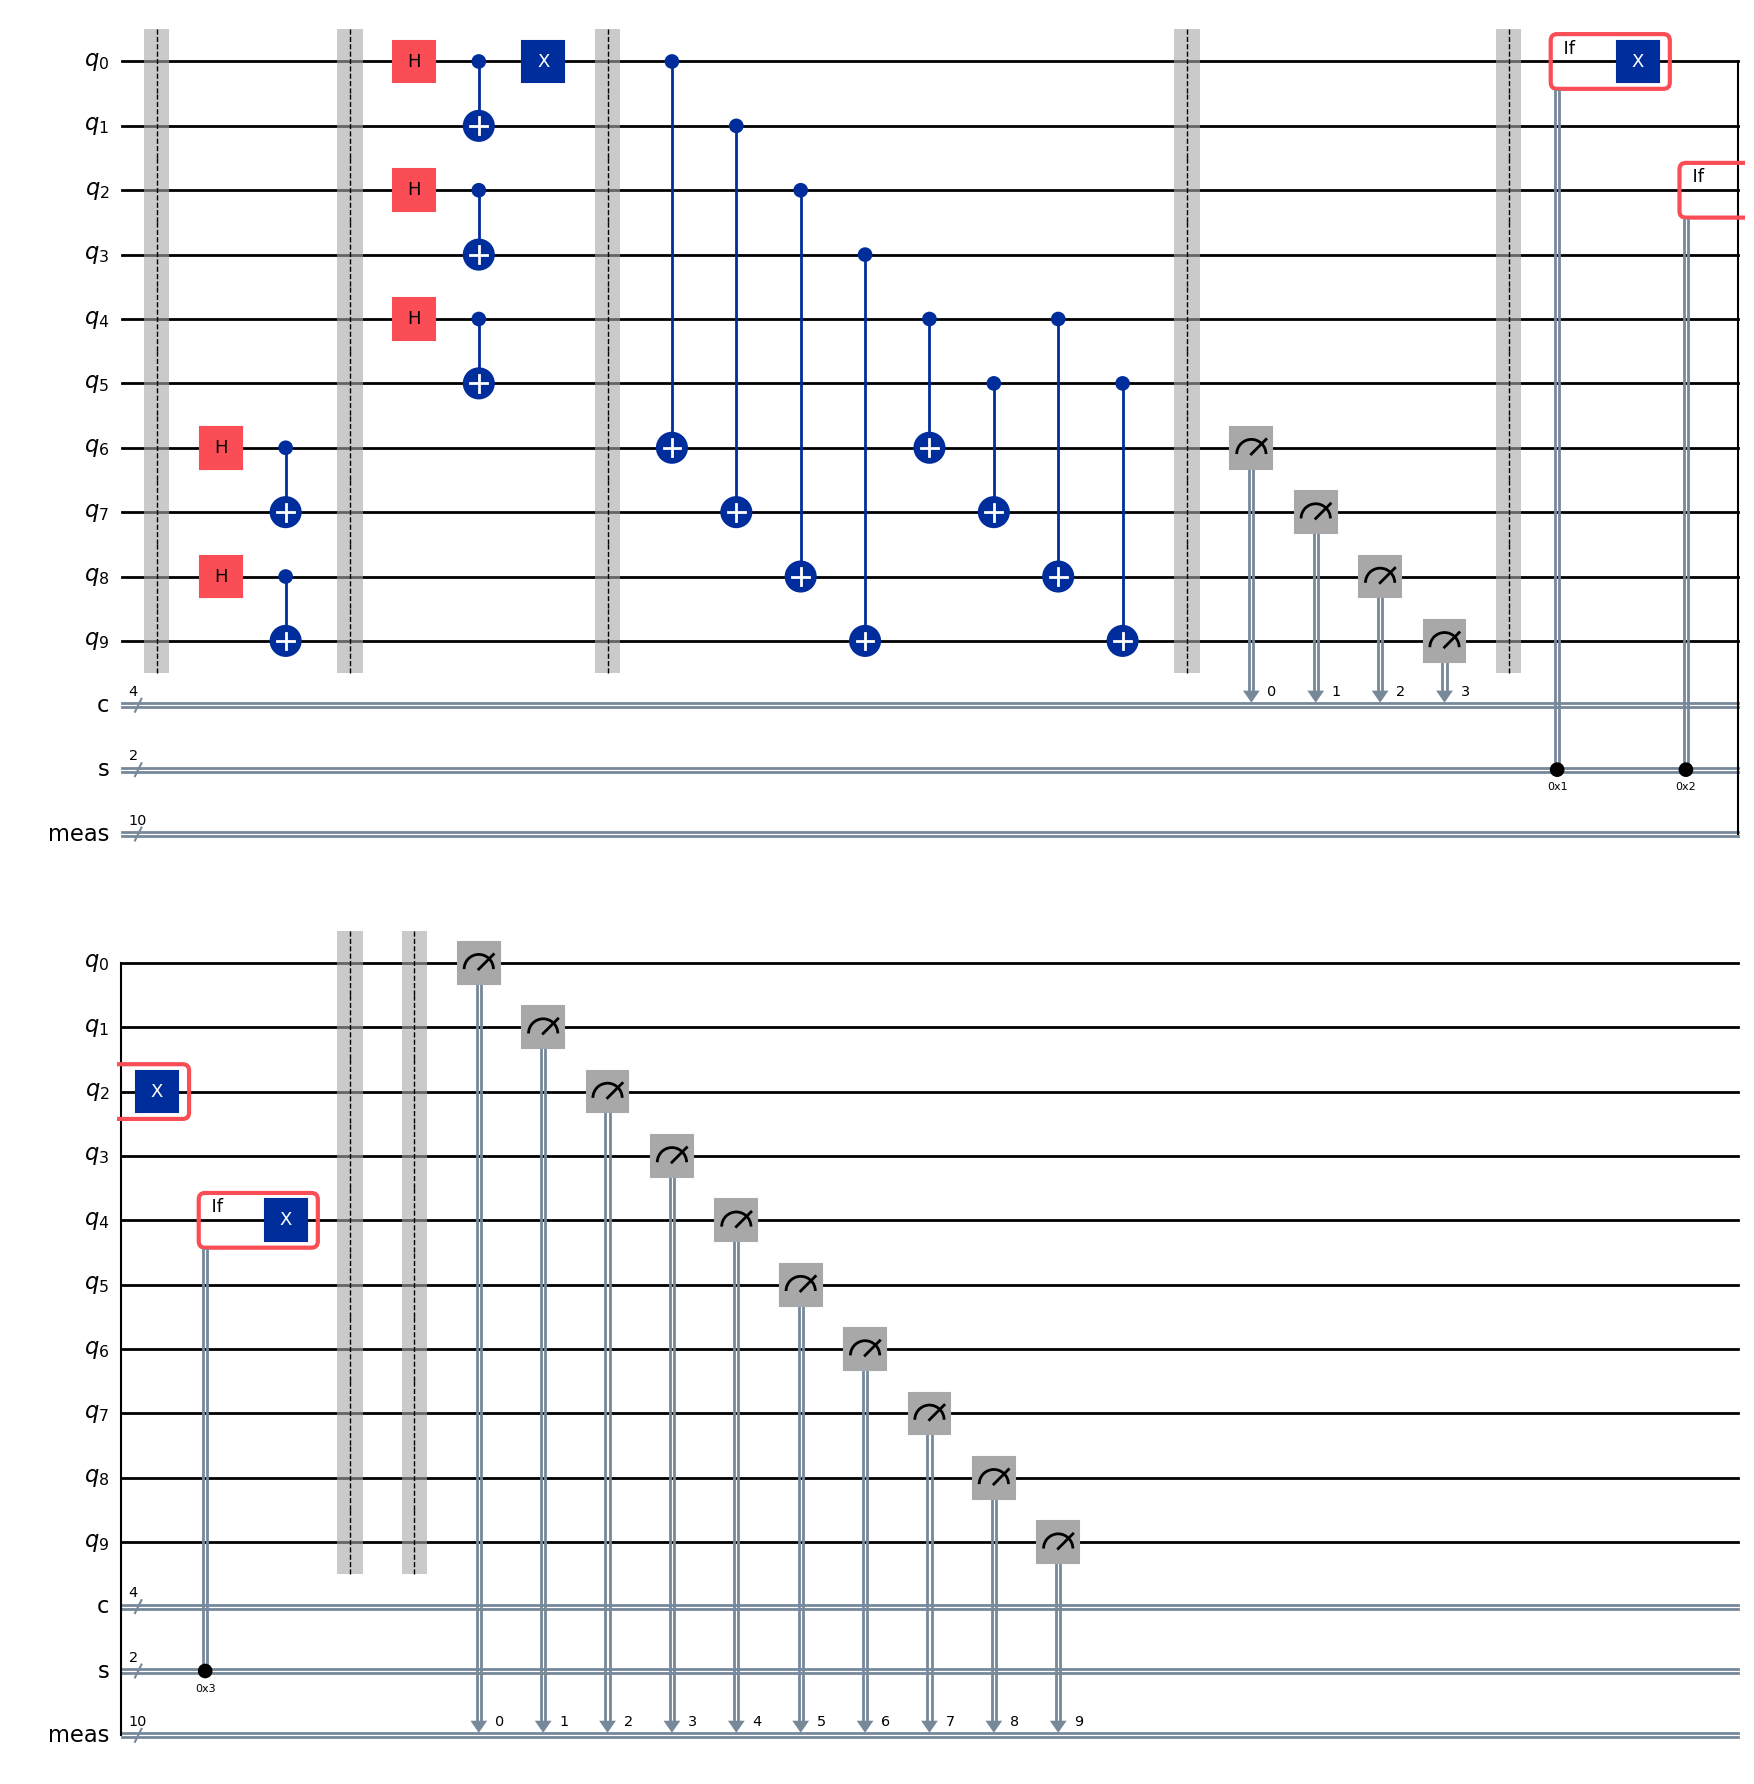

In [3]:
from circuits.circuits import generate_qec_circuit

n_exchanged_pairs = 3
flipped_qubit = 0
qc = generate_qec_circuit(n_exchanged_pairs, flipped_qubit)
qc.draw(output='mpl')

{'01010000111111001111 110 010100': 3, '10010011110000000011 110 100100': 1, '10101100111111001100 110 101011': 3, '10010000110011001111 110 100100': 2, '10101111110000111100 110 101011': 2, '10010000000011001100 110 100100': 1, '01011100001111110000 110 010111': 1, '10101100000011000011 110 101011': 2, '10100000111100000011 110 101000': 2, '01011111000011000011 110 010111': 3, '01100011001111001100 110 011000': 1, '01100011000011000011 110 011000': 2, '10101100001111110000 110 101011': 1, '10010011110000110011 110 100100': 5, '01100011110011111111 110 011000': 1, '10100000110000000000 110 101000': 1, '01011100000011000011 110 010111': 1, '01101111001100111100 110 011011': 2, '10011100110000001111 110 100111': 1, '10010011001111000000 110 100100': 3, '10101100000011110011 110 101011': 1, '10100011001111001100 110 101000': 3, '10101111110011111100 110 101011': 1, '10101111110000001100 110 101011': 1, '01101111000000000011 110 011011': 1, '01010000110011000000 110 010100': 1, '1001000011

Text(0.5, 1.0, 'QEC Performance')

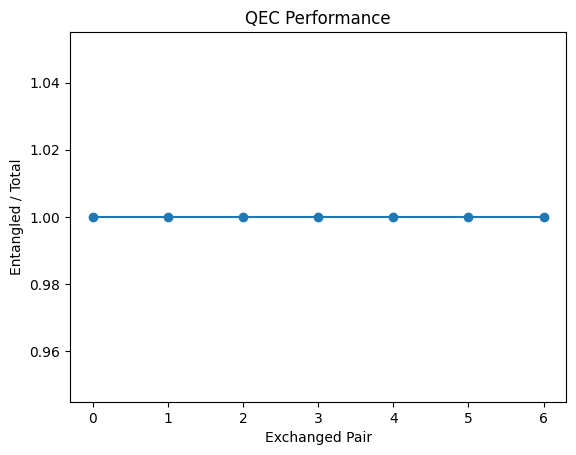

In [39]:
from qiskit_aer import AerSimulator
import numpy as np
import matplotlib.pyplot as plt
    
sim = AerSimulator()

shots = 1000
job = sim.run(qc, shots=shots)
result = job.result()

counts = result.get_counts()

print(counts)

bit_entangled = np.zeros(n_exchanged_pairs, dtype=int)

n_qubits = qc.num_qubits
for key in counts.keys():
    for pair in range(n_exchanged_pairs):   
        id_txt = n_qubits - 2*pair - 2     
        if key[id_txt] == key[id_txt+1]:
            bit_entangled[pair] += counts[key]

plt.plot(bit_entangled/shots,'-o')
plt.xlabel('Exchanged Pair')
plt.ylabel('Entangled / Total')
plt.title('QEC Performance')
